Prepare the execution environment and set the random seed.

In [1]:
import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from reproduce.bivariate import set_seed
set_seed(0)

Get the dataset.

In [2]:
from data.bivariate import SIM
from sklearn.preprocessing import StandardScaler

data = SIM(
    pair_id=3,
    double=True,
    preprocessor=StandardScaler()
)
x = data.cause[:, :1].cpu().numpy()
y = data.effect[:, :1].cpu().numpy()

Bivariate causal discovery by QPE-k.

In [3]:
from qpek import qpe_k

qpe_12, score_12, qpe_21, score_21 = qpe_k(x, y)
print('Score of X->Y:', score_12)
print('Score of Y->X:', score_21)

Score of X->Y: -0.23771906124051187
Score of Y->X: -1.0420882627669126


Visualize QPE from QPE-k.

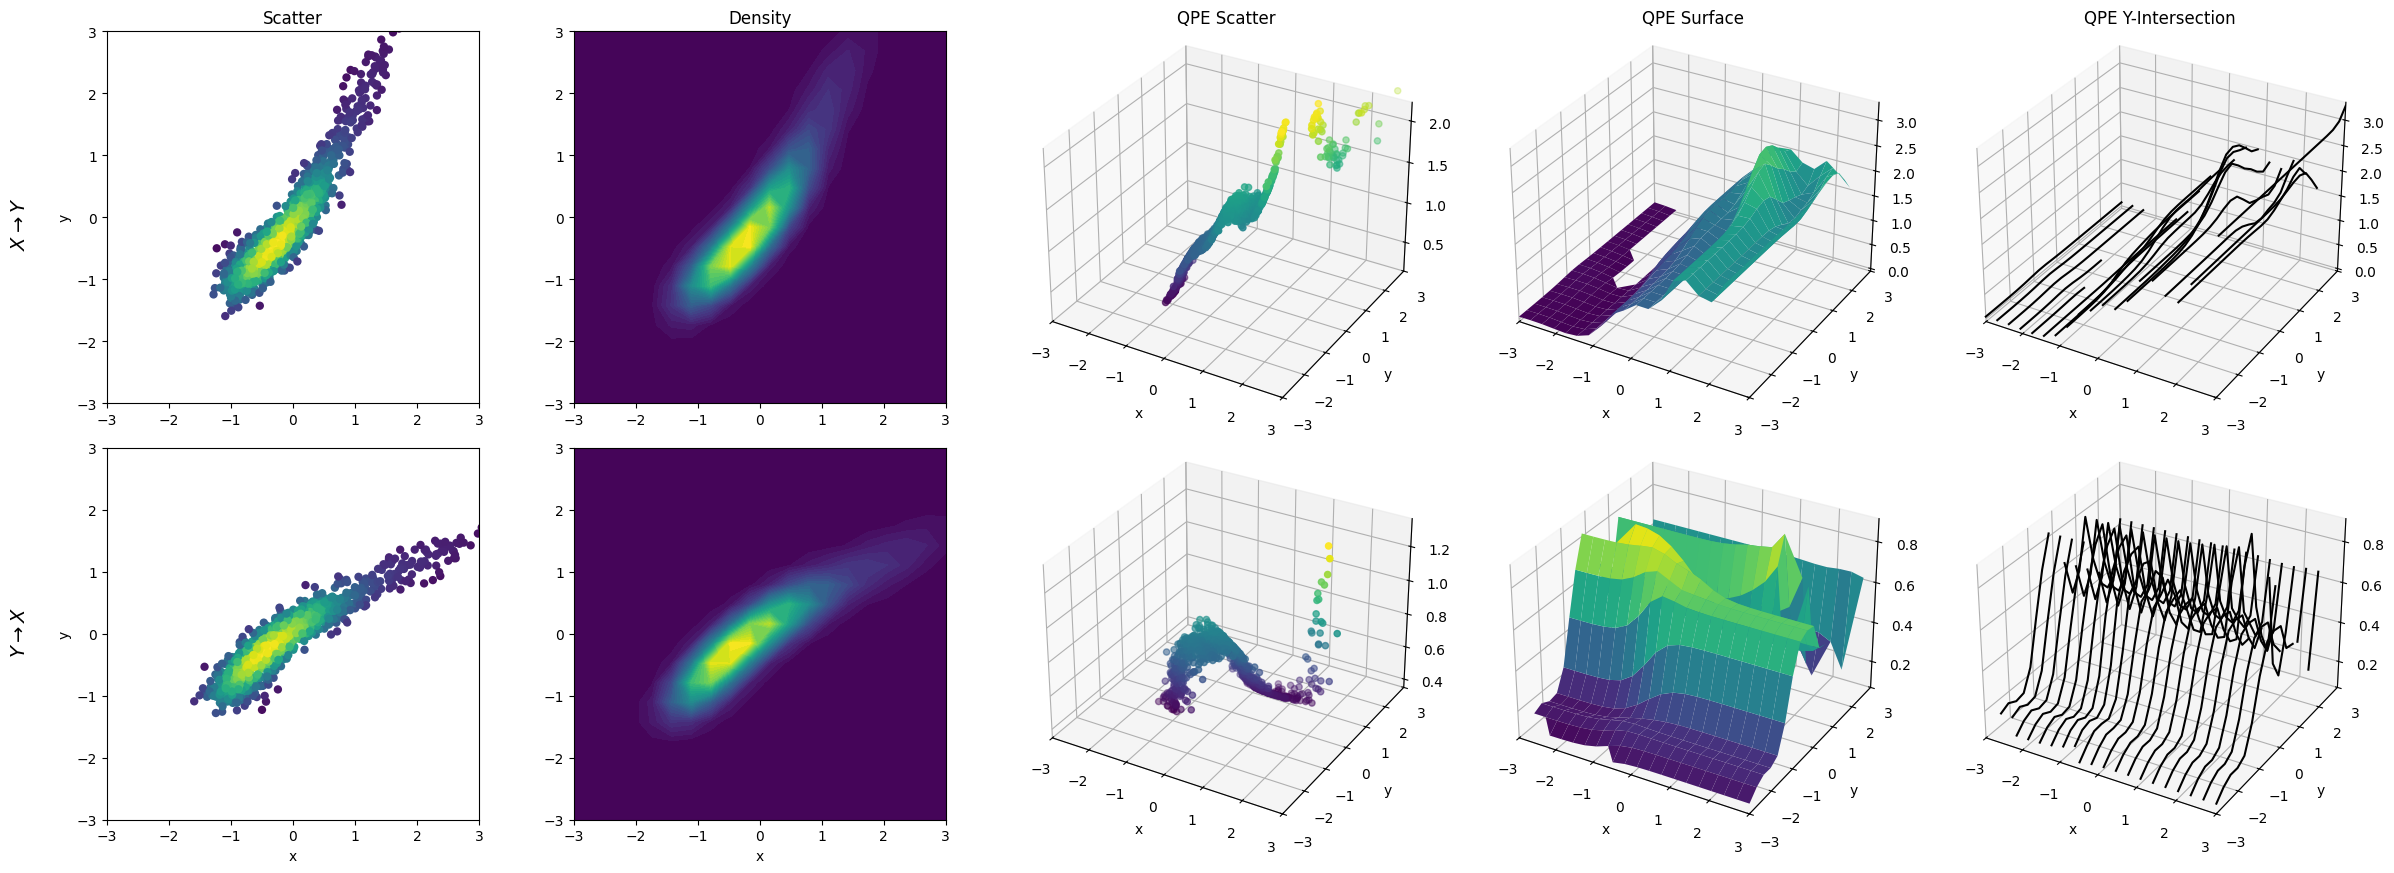

In [4]:
from visualize import *
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(24, 8.5))
gs = fig.add_gridspec(2, 5, width_ratios=[1, 1, 1, 1, 1])
axes = [[None for j in range(5)] for i in range(2)]

axes[0][0] = fig.add_subplot(gs[0, 0])
visualize_scatter(axes[0][0], x, y)
axes[0][1] = fig.add_subplot(gs[0, 1])
visualize_density(axes[0][1], x, y)
axes[0][2] = fig.add_subplot(gs[0, 2], projection='3d')
visualize_qpe_scatter(axes[0][2], qpe_12, x, y)
axes[0][3] = fig.add_subplot(gs[0, 3], projection='3d')
visualize_qpe_surface(axes[0][3], qpe_12)
axes[0][4] = fig.add_subplot(gs[0, 4], projection='3d')
visualize_qpe_intersection_y(axes[0][4], qpe_12)

axes[1][0] = fig.add_subplot(gs[1, 0])
visualize_scatter(axes[1][0], y, x)
axes[1][1] = fig.add_subplot(gs[1, 1])
visualize_density(axes[1][1], y, x)
axes[1][2] = fig.add_subplot(gs[1, 2], projection='3d')
visualize_qpe_scatter(axes[1][2], qpe_21, y, x)
axes[1][3] = fig.add_subplot(gs[1, 3], projection='3d')
visualize_qpe_surface(axes[1][3], qpe_21)
axes[1][4] = fig.add_subplot(gs[1, 4], projection='3d')
visualize_qpe_intersection_y(axes[1][4], qpe_21)

for i in range(2):
    for j in range(5):
        axes[i][j].set_xlim(-3, 3)
        axes[i][j].set_ylim(-3, 3)
        if i == 1 or j in [2, 3, 4]:
            axes[i][j].set_xlabel("x")
        if j == 0 or j in [2, 3, 4]:
            axes[i][j].set_ylabel("y")
        if j in [2, 3, 4]:
            axes[i][j].set_box_aspect(None, zoom=1.1)
            axes[i][j].set_aspect('auto')
        else:
            axes[i][j].set_aspect('equal', adjustable='box')


axes[0][0].set_title(r"Scatter")
axes[0][1].set_title(r"Density")
axes[0][2].set_title(r"QPE Scatter")
axes[0][3].set_title(r"QPE Surface")
axes[0][4].set_title(r"QPE Y-Intersection")

fig.text(0.01, 0.75, r"$X\to Y$", va='center', ha='center', rotation=90, fontsize=14)
fig.text(0.01, 0.27, r"$Y\to X$", va='center', ha='center', rotation=90, fontsize=14)


plt.tight_layout(rect=[0.01, -0.02, 1, 1.02])
plt.show()